In [ ]:
#install.packages("qqman")
#install.packages("ggplot2")
#install.packages("ggrepel")
#install.packages("dplyr")

awk -F',' 'NR>1 {
    chr = $1
    pos = $2
    start = pos - 1
    end   = pos
    snp_id = "snp"NR  # or any desired ID
    print chr, start, end, snp_id
}' OFS='\t' 20241021_SNPs_GWAS_match_pvalue_uniqueSNPs.csv > 20241021_SNPs_GWAS_match_pvalue_uniqueSNPs.bed

############################################
# gencode.v47.basic.annotation.gtf -> gencode.v47.basic.TSS.bed
############################################

awk -F'\t' 'BEGIN{OFS="\t"}
$3 == "gene" {
    # columns: 1=chr, 4=start, 5=end, 7=strand, 9=attributes
    split($9, attr, ";");
    # defaults
    geneName = "NA";
    geneType = "NA";
    # parse out gene_name and gene_type from attributes
    for(i=1; i<=length(attr); i++){
        if(attr[i] ~ /gene_name/){
            match(attr[i], /"([^"]+)"/, a); 
            geneName = a[1];
        }
        if(attr[i] ~ /gene_type/){
            match(attr[i], /"([^"]+)"/, a);
            geneType = a[1];
        }
    }
    # Determine TSS based on strand
    if($7 == "+"){
        tss = $4;
    } else {
        tss = $5;
    }
    # print BED: chr, TSS, TSS, geneName, geneType, strand
    print $1, tss, tss, geneName, geneType, $7
}' gencode.v47.basic.annotation.gtf \
> gencode.v47.basic.TSS.bed

In [ ]:
############################################
# Find nearest TSS for each SNP
############################################

sed 's/^chr//' /media/zihengc/T7/genome/gencode.v47.basic.TSS.20241223.bed > \
    /media/zihengc/T7/genome/gencode.v47.basic.TSS.20241223.nochr.bed
sort -k1,1 -k2,2n 20241021_SNPs_GWAS_match_pvalue_uniqueSNPs.bed \
    > 20241021_SNPs_GWAS_match_pvalue_uniqueSNPs.sorted.bed

sort -k1,1 -k2,2n /media/zihengc/T7/genome/gencode.v47.basic.TSS.20241223.nochr.bed \
    > /media/zihengc/T7/genome/gencode.v47.basic.TSS.20241223.nochr.sorted.bed
bedtools closest \
    -a indexing/20241021_SNPs_GWAS_match_pvalue_uniqueSNPs.sorted.bed \
    -b /media/zihengc/T7/genome/gencode.v47.basic.TSS.20241223.nochr.sorted.bed \
    -D a \
> 20241021_SNPs_GWAS_match_pvalue_uniqueSNPs_TSS.bed

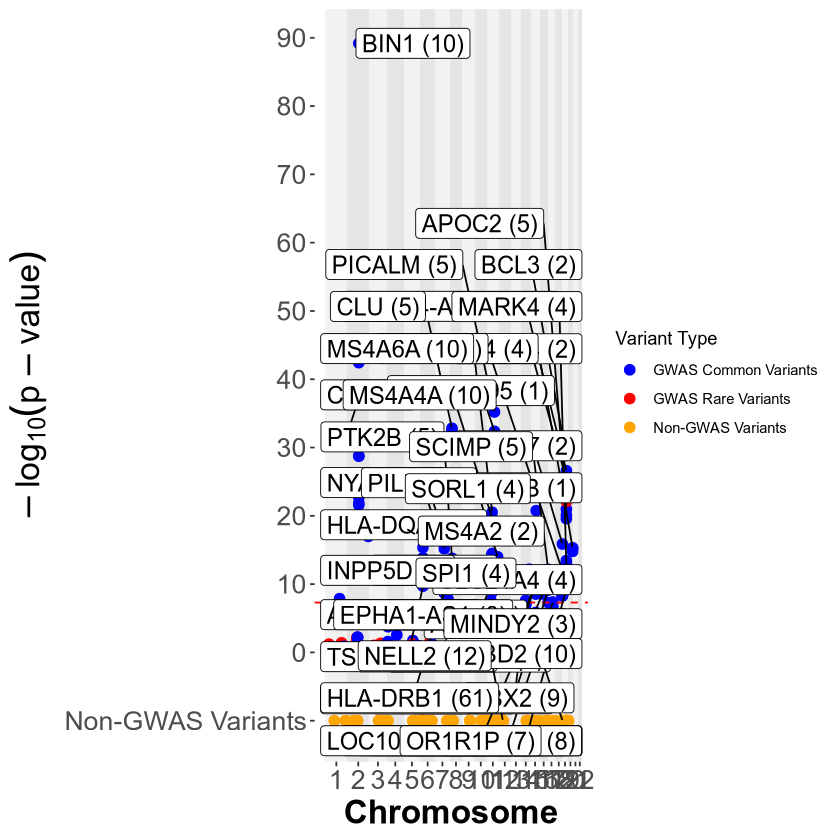

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load your data
df <- read.csv("indexing/20241021_SNPs_GWAS_match_pvalue_uniqueSNPs.csv", header = TRUE)

# Ensure chromosome numbers are numeric and exclude X/Y chromosomes if present
df <- df %>% 
  filter(chr_number %in% 1:22) %>%
  mutate(chr_number = as.numeric(chr_number))

# Define chromosome sizes (hg38 reference genome)
chrom_sizes <- data.frame(
  chr_number = 1:22,
  chr_size = c(
    248956422, 242193529, 198295559, 190214555, 181538259,
    170805979, 159345973, 145138636, 138394717, 133797422,
    135086622, 133275309, 114364328, 107043718, 101991189,
    90338345, 83257441, 80373285, 58617616, 64444167,
    46709983, 50818468
  )
)

# Calculate cumulative positions for chromosomes
chrom_sizes <- chrom_sizes %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Merge SNP data with chromosome sizes
don <- df %>%
  left_join(chrom_sizes, by = "chr_number") %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot)

# Calculate the number of SNPs per nearest_gene, including all SNPs
gene_counts <- don %>%
  group_by(nearest_gene) %>%
  summarise(SNP_count = n())

# Merge gene counts back to the main data
don <- don %>%
  left_join(gene_counts, by = "nearest_gene") %>%
  mutate(label = paste0(nearest_gene, " (", SNP_count, ")"))

# Define significance threshold
significance_threshold <- -log10(5e-8)

# Create a new variable 'Variant_Type'
don <- don %>%
  mutate(
    Variant_Type = case_when(
      !is.na(Bellenguez_p_value_negLog10) & EUR > 0.01 ~ "GWAS Common Variants",
      !is.na(Bellenguez_p_value_negLog10) & EUR <= 0.01 ~ "GWAS Rare Variants",
      is.na(Bellenguez_p_value_negLog10) ~ "Non-GWAS Variants"
    )
  )

# Identify significant SNPs
don <- don %>%
  mutate(is_significant = Bellenguez_p_value_negLog10 > significance_threshold)

# Prepare data for labeling significant SNPs
label_all <- FALSE  # Set to TRUE to label all SNPs regardless of significance

if (label_all) {
  # Label one SNP per gene, regardless of significance
  label_data <- don %>%
    group_by(nearest_gene) %>%
    slice_max(order_by = Bellenguez_p_value_negLog10, n = 1, with_ties = FALSE) %>%
    ungroup()
} else {
  # Label only significant SNPs
  label_data <- don %>%
    filter(is_significant) %>%
    group_by(nearest_gene) %>%
    slice_max(order_by = Bellenguez_p_value_negLog10, n = 1, with_ties = FALSE) %>%
    ungroup()
}

# Identify rows with missing Bellenguez_p_value_negLog10
missing_pvalue_data <- don %>%
  filter(is.na(Bellenguez_p_value_negLog10))

# Get the list of nearest_genes already labeled
labeled_genes <- unique(label_data$nearest_gene)

# Exclude genes already labeled
missing_pvalue_data <- missing_pvalue_data %>%
  filter(!nearest_gene %in% labeled_genes)

# Count the number of SNPs per nearest_gene in missing_pvalue_data
missing_gene_counts <- missing_pvalue_data %>%
  group_by(nearest_gene) %>%
  summarise(SNP_count_missing = n())

# Only include genes with counts more than 2
genes_with_counts_more_than_2 <- missing_gene_counts %>%
  filter(SNP_count_missing >= 3) %>%
  pull(nearest_gene)

# Filter missing_pvalue_data to only include these genes
missing_pvalue_data <- missing_pvalue_data %>%
  filter(nearest_gene %in% genes_with_counts_more_than_2)

# Select one row per nearest_gene for missing p-values
missing_label_data <- missing_pvalue_data %>%
  group_by(nearest_gene) %>%
  slice(1) %>%  # Take the first occurrence per gene
  ungroup() %>%
  mutate(Bellenguez_p_value_negLog10 = -10)  # Set y-position to -10

# Adjust y-axis limits to include y = -10
y_min <- min(don$Bellenguez_p_value_negLog10, na.rm = TRUE)
y_min <- min(y_min, -10)  # Ensure y_min includes -10

# Find the minimum and maximum Chromosome positions
x_min <- min(don$Chromosome, na.rm = TRUE)
x_max <- max(don$Chromosome, na.rm = TRUE)

# Calculate the total x-range
x_range <- x_max - x_min

# Calculate new x-axis limits with 10% margin on both sides
x_min_new <- x_min - 0.05 * x_range
x_max_new <- x_max + 0.05 * x_range

# Create a data frame for chromosome shading
chrom_shading <- chrom_sizes %>%
  mutate(color = rep(c("grey90", "grey80"), length.out = n()))

# Set label size and max overlaps
label_size <- 5
max_overlaps_value <- Inf

# Determine y-axis breaks at every 10 units
max_y <- ceiling(max(don$Bellenguez_p_value_negLog10, na.rm = TRUE))
breaks_y <- seq(0, max_y, by = 10)
breaks_y <- c(-10, breaks_y)

# Create the Manhattan plot
manhattan_plot <- ggplot() +
  # Add shaded rectangles for chromosomes
  geom_rect(
    data = chrom_shading,
    aes(
      xmin = tot,
      xmax = tot + chr_size,
      ymin = -Inf,
      ymax = Inf,
      fill = color
    ),
    alpha = 0.5
  ) +
  # Add SNP points (including missing p-values)
  geom_point(
    data = don,
    aes(
      x = Chromosome,
      y = ifelse(is.na(Bellenguez_p_value_negLog10), -10, Bellenguez_p_value_negLog10),
      color = Variant_Type
    ),
    size = 2.6
  ) +
  # Adjust fill scale for chromosome shading
  scale_fill_identity() +
  # Color scale for Variant_Type
  scale_color_manual(
    values = c(
      "GWAS Common Variants" = "blue",
      "GWAS Rare Variants" = "red",
      "Non-GWAS Variants" = "orange"
    ),
    name = "Variant Type"
  ) +
  # x-axis labels with adjusted limits and expansion
  scale_x_continuous(
    labels = chrom_sizes$chr_number,
    breaks = chrom_sizes$center,
    limits = c(x_min_new, x_max_new),
    expand = c(0, 0)
  ) +
  # Adjust y-axis limits and breaks
  scale_y_continuous(
    limits = c(y_min - 1, NA),
    breaks = breaks_y,
    labels = function(x) ifelse(x == -10, "Non-GWAS Variants", x)
  ) +
  # Significance threshold line
  geom_hline(
    yintercept = significance_threshold,
    color = "red",
    linetype = "dashed"
  ) +
  # Labels for significant SNPs
  geom_label_repel(
    data = label_data,
    aes(
      x = Chromosome,
      y = Bellenguez_p_value_negLog10,
      label = label
    ),
    size = label_size,
    max.overlaps = max_overlaps_value
  ) +
  # Labels for missing p-values at y = -10
  geom_label_repel(
    data = missing_label_data,
    aes(
      x = Chromosome,
      y = Bellenguez_p_value_negLog10,
      label = label
    ),
    size = label_size,
    max.overlaps = max_overlaps_value
  ) +
  theme_bw() +
  theme(
    legend.position = "right",  # Show the legend
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),  # Hide vertical major grid lines if desired
    panel.grid.minor.x = element_blank(),  # Hide vertical minor grid lines
    panel.grid.major.y = element_blank(),  # Hide horizontal major grid lines
    panel.grid.minor.y = element_blank(),  # Hide horizontal minor grid lines
    axis.title.x = element_text(size = 20, face = "bold"),  # Adjust x-axis title size
    axis.title.y = element_text(size = 20, face = "bold"),  # Adjust y-axis title size
    axis.text.x = element_text(size = 16),  # Adjust x-axis tick label size
    axis.text.y = element_text(size = 16)   # Adjust y-axis tick label size
  ) +
  labs(
    x = "Chromosome",
    y = expression(-log[10](p-value))
  )

# Save the Manhattan plot with high resolution and increased width
ggsave("manhattan_plot_rare_common_gwas.pdf", plot = manhattan_plot, width = 28, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


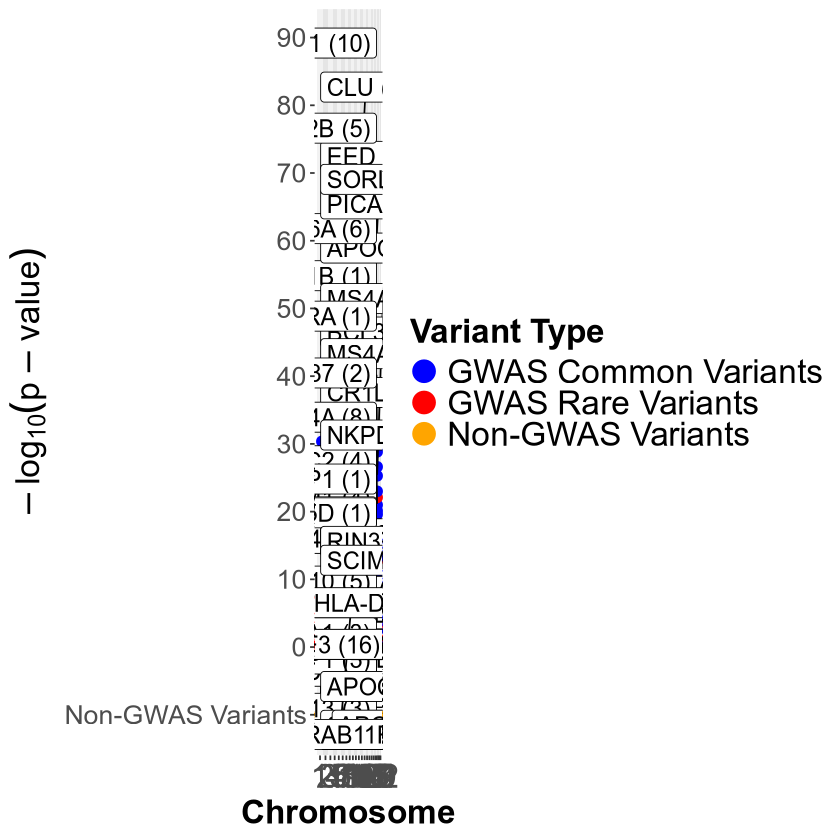

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation
library(grid)     # For unit function used in theme

# Load your data
df <- read.csv("indexing/20250121_SNPs_GWAS_match_pvalue_uniqueSNPs.csv", header = TRUE)

# Ensure chromosome numbers are numeric and exclude X/Y chromosomes if present
df <- df %>% 
  filter(chr_number %in% 1:22) %>%
  mutate(chr_number = as.numeric(chr_number))

# Define chromosome sizes (hg38 reference genome)
chrom_sizes <- data.frame(
  chr_number = 1:22,
  chr_size = c(
    248956422, 242193529, 198295559, 190214555, 181538259,
    170805979, 159345973, 145138636, 138394717, 133797422,
    135086622, 133275309, 114364328, 107043718, 101991189,
    90338345, 83257441, 80373285, 58617616, 64444167,
    46709983, 50818468
  )
)

# Calculate cumulative positions for chromosomes
chrom_sizes <- chrom_sizes %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Merge SNP data with chromosome sizes
don <- df %>%
  left_join(chrom_sizes, by = "chr_number") %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot)

# Calculate the number of SNPs per closest_protein_coding_gene_TSS, including all SNPs
gene_counts <- don %>%
  group_by(closest_protein_coding_gene_TSS) %>%
  summarise(SNP_count = n())

# Merge gene counts back to the main data
don <- don %>%
  left_join(gene_counts, by = "closest_protein_coding_gene_TSS") %>%
  mutate(label = paste0(closest_protein_coding_gene_TSS, " (", SNP_count, ")"))

# Define significance threshold
significance_threshold <- -log10(5e-8)

# Create a new variable 'Variant_Type'
don <- don %>%
  mutate(
    Variant_Type = case_when(
      !is.na(Bellenguez_p_value_negLog10) & EUR > 0.01 ~ "GWAS Common Variants",
      !is.na(Bellenguez_p_value_negLog10) & EUR <= 0.01 ~ "GWAS Rare Variants",
      is.na(Bellenguez_p_value_negLog10) ~ "Non-GWAS Variants"
    )
  )

# Identify significant SNPs
don <- don %>%
  mutate(is_significant = Bellenguez_p_value_negLog10 > significance_threshold)

# Prepare data for labeling significant SNPs
label_all <- FALSE  # Set to TRUE to label all SNPs regardless of significance

if (label_all) {
  # Label one SNP per gene, regardless of significance
  label_data <- don %>%
    group_by(closest_protein_coding_gene_TSS) %>%
    slice_max(order_by = Bellenguez_p_value_negLog10, n = 1, with_ties = FALSE) %>%
    ungroup()
} else {
  # Label only significant SNPs
  label_data <- don %>%
    filter(is_significant) %>%
    group_by(closest_protein_coding_gene_TSS) %>%
    slice_max(order_by = Bellenguez_p_value_negLog10, n = 1, with_ties = FALSE) %>%
    ungroup()
}

# Identify rows with missing Bellenguez_p_value_negLog10
missing_pvalue_data <- don %>%
  filter(is.na(Bellenguez_p_value_negLog10))

# Get the list of closest_protein_coding_gene_TSSs already labeled
labeled_genes <- unique(label_data$closest_protein_coding_gene_TSS)

# Exclude genes already labeled
missing_pvalue_data <- missing_pvalue_data %>%
  filter(!closest_protein_coding_gene_TSS %in% labeled_genes)

# Count the number of SNPs per closest_protein_coding_gene_TSS in missing_pvalue_data
missing_gene_counts <- missing_pvalue_data %>%
  group_by(closest_protein_coding_gene_TSS) %>%
  summarise(SNP_count_missing = n())

# Only include genes with counts more than 2
genes_with_counts_more_than_2 <- missing_gene_counts %>%
  filter(SNP_count_missing >= 3) %>%
  pull(closest_protein_coding_gene_TSS)

# Filter missing_pvalue_data to only include these genes
missing_pvalue_data <- missing_pvalue_data %>%
  filter(closest_protein_coding_gene_TSS %in% genes_with_counts_more_than_2)

# Select one row per closest_protein_coding_gene_TSS for missing p-values
missing_label_data <- missing_pvalue_data %>%
  group_by(closest_protein_coding_gene_TSS) %>%
  slice(1) %>%  # Take the first occurrence per gene
  ungroup() %>%
  mutate(Bellenguez_p_value_negLog10 = -10)  # Set y-position to -10

# Adjust y-axis limits to include y = -10
y_min <- min(don$Bellenguez_p_value_negLog10, na.rm = TRUE)
y_min <- min(y_min, -10)  # Ensure y_min includes -10

# Find the minimum and maximum Chromosome positions
x_min <- min(don$Chromosome, na.rm = TRUE)
x_max <- max(don$Chromosome, na.rm = TRUE)

# Calculate the total x-range
x_range <- x_max - x_min

# Calculate new x-axis limits with 10% margin on both sides
x_min_new <- x_min - 0.05 * x_range
x_max_new <- x_max + 0.05 * x_range

# Create a data frame for chromosome shading
chrom_shading <- chrom_sizes %>%
  mutate(color = rep(c("grey90", "grey80"), length.out = n()))

# Set label size and max overlaps
label_size <- 5
max_overlaps_value <- Inf

# Determine y-axis breaks at every 10 units
max_y <- ceiling(max(don$Bellenguez_p_value_negLog10, na.rm = TRUE))
breaks_y <- seq(0, max_y, by = 10)
breaks_y <- c(-10, breaks_y)

# Define legend text sizes and symbol sizes
legend_title_size <- 20  # Size for legend title
legend_text_size <- 20   # Size for legend text
legend_symbol_size <- 6  # Size for legend symbols (dots)

# Create the Manhattan plot
manhattan_plot <- ggplot() +
  # Add shaded rectangles for chromosomes
  geom_rect(
    data = chrom_shading,
    aes(
      xmin = tot,
      xmax = tot + chr_size,
      ymin = -Inf,
      ymax = Inf,
      fill = color
    ),
    alpha = 0.5
  ) +
  # Add SNP points (including missing p-values)
  geom_point(
    data = don,
    aes(
      x = Chromosome,
      y = ifelse(is.na(Bellenguez_p_value_negLog10), -10, Bellenguez_p_value_negLog10),
      color = Variant_Type
    ),
    size = 2.6
  ) +
  # Adjust fill scale for chromosome shading
  scale_fill_identity() +
  # Color scale for Variant_Type with adjusted legend symbols
  scale_color_manual(
    values = c(
      "GWAS Common Variants" = "blue",
      "GWAS Rare Variants" = "red",
      "Non-GWAS Variants" = "orange"
    ),
    name = "Variant Type",
    guide = guide_legend(
      override.aes = list(size = legend_symbol_size)  # Adjust legend symbol size
    )
  ) +
  # x-axis labels with adjusted limits and expansion
  scale_x_continuous(
    labels = chrom_sizes$chr_number,
    breaks = chrom_sizes$center,
    limits = c(x_min_new, x_max_new),
    expand = c(0, 0)
  ) +
  # Adjust y-axis limits and breaks
  scale_y_continuous(
    limits = c(y_min - 1, NA),
    breaks = breaks_y,
    labels = function(x) ifelse(x == -10, "Non-GWAS Variants", x)
  ) +
  # Significance threshold line
  geom_hline(
    yintercept = significance_threshold,
    color = "red",
    linetype = "dashed"
  ) +
  # Labels for significant SNPs
  geom_label_repel(
    data = label_data,
    aes(
      x = Chromosome,
      y = Bellenguez_p_value_negLog10,
      label = label
    ),
    size = label_size,
    max.overlaps = max_overlaps_value
  ) +
  # Labels for missing p-values at y = -10
  geom_label_repel(
    data = missing_label_data,
    aes(
      x = Chromosome,
      y = Bellenguez_p_value_negLog10,
      label = label
    ),
    size = label_size,
    max.overlaps = max_overlaps_value
  ) +
  theme_bw() +
  theme(
    legend.position = "right",  # Show the legend on the right
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),  # Hide vertical major grid lines if desired
    panel.grid.minor.x = element_blank(),  # Hide vertical minor grid lines
    panel.grid.major.y = element_blank(),  # Hide horizontal major grid lines
    panel.grid.minor.y = element_blank(),  # Hide horizontal minor grid lines
    axis.title.x = element_text(size = 20, face = "bold"),  # Adjust x-axis title size
    axis.title.y = element_text(size = 20, face = "bold"),  # Adjust y-axis title size
    axis.text.x = element_text(size = 20),  # Adjust x-axis tick label size
    axis.text.y = element_text(size = 16),  # Adjust y-axis tick label size
    legend.title = element_text(size = legend_title_size, face = "bold"),  # Adjust legend title size
    legend.text = element_text(size = legend_text_size),  # Adjust legend text size
    legend.key.size = unit(legend_symbol_size + 1, "points")  # Adjust the space allocated for legend symbols
  ) +
  labs(
    x = "Chromosome",
    y = expression(-log[10](p-value))
  )

# Save the Manhattan plot with high resolution and increased width
ggsave("manhattan_plot_rare_common_gwas.pdf", plot = manhattan_plot, width = 28, height = 8, dpi = 300)
ggsave("manhattan_plot_rare_common_gwas.png", plot = manhattan_plot, width = 28, height = 8, dpi = 300)
# Display the plot in the R console
print(manhattan_plot)


Loading required package: ggplot2


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




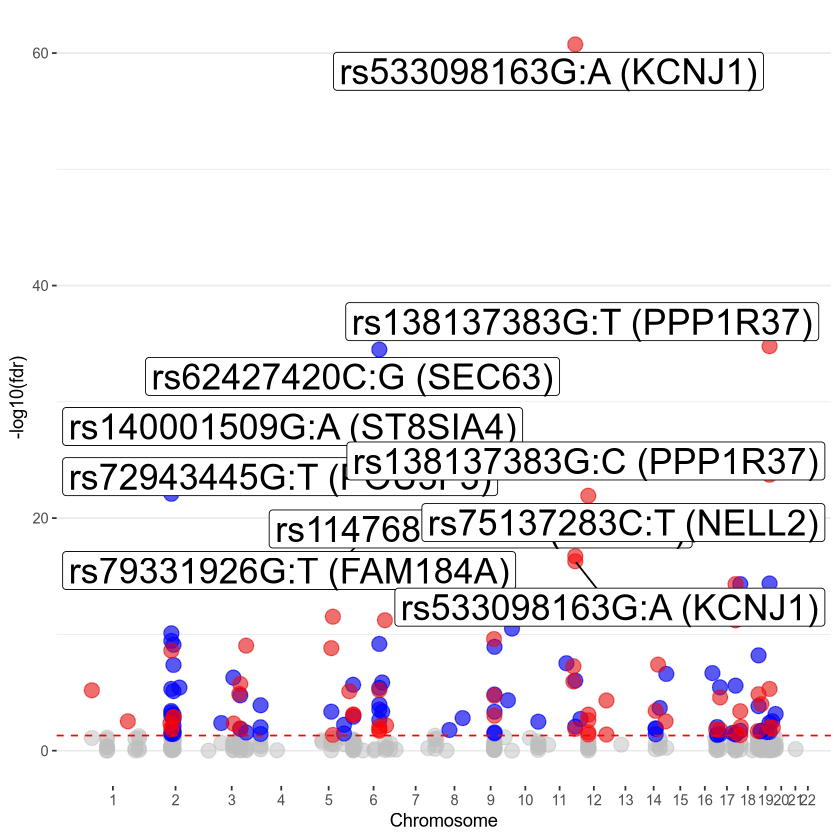

In [1]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Rare", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 15, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*3) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 0.6, size = 1.3*3) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*3)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*3) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_mac_rare.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


In [ ]:
#Select the SNPs that have ML prediction significance
import pandas as pd

df = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_20250324.csv' )
len(df['RSID'].unique())

599

In [ ]:
#Select the SNPs that have ML prediction significance
import pandas as pd

# Load data
df = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_20250324.csv', index_col=0)

# Sum of absolute values across immune-related columns
sum_immune = df[[
    'ML_majorminor_logFC_genomic_H1_resting-model',
    'ML_majorminor_logFC_genomic_THP1_IFNB-Calvin',
    'ML_majorminor_logFC_genomic_THP1_IFNG-Calvin',
    'ML_majorminor_logFC_genomic_THP1_LPSIFNG-Calvin',
    'ML_majorminor_logFC_genomic_THP1_LPSIFNGvsIFNG',
    'ML_majorminor_logFC_genomic_THP1_LPSIFNGvsNaive',
    'ML_majorminor_logFC_genomic_THP1_Naive-Calvin',
    'ML_majorminor_logFC_genomic_WTC11_IFNB',
    'ML_majorminor_logFC_genomic_WTC11_resting'
]].abs().sum(axis=1)

# Filter where sum > 0
sum_immune[sum_immune > 0].index.to_series().to_csv('indexing/ML_sig_variants_immune.txt', index=False, header=False)

import pandas as pd
df = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_20250324.csv',index_col = 0 )
df.iloc[:,-17:].columns
sum_brain = df[[
       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model',
       'ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model',
       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB',
       'ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC',]].abs().sum(axis=1)
sum_brain[sum_brain > 0].index.to_series().to_csv('indexing/ML_sig_variants_brain.txt', index=False, header=False)

Retained 553 of 553 variants after filter.

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_number = as.numeric(gsub("chr", "", chr))`.
Caused by warning:
! NAs introduced by coercion”
Retained 553 of 553 variants after filter.

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_number = as.numeric(gsub("chr", "", chr))`.
Caused by warning:
! NAs introduced by coercion”


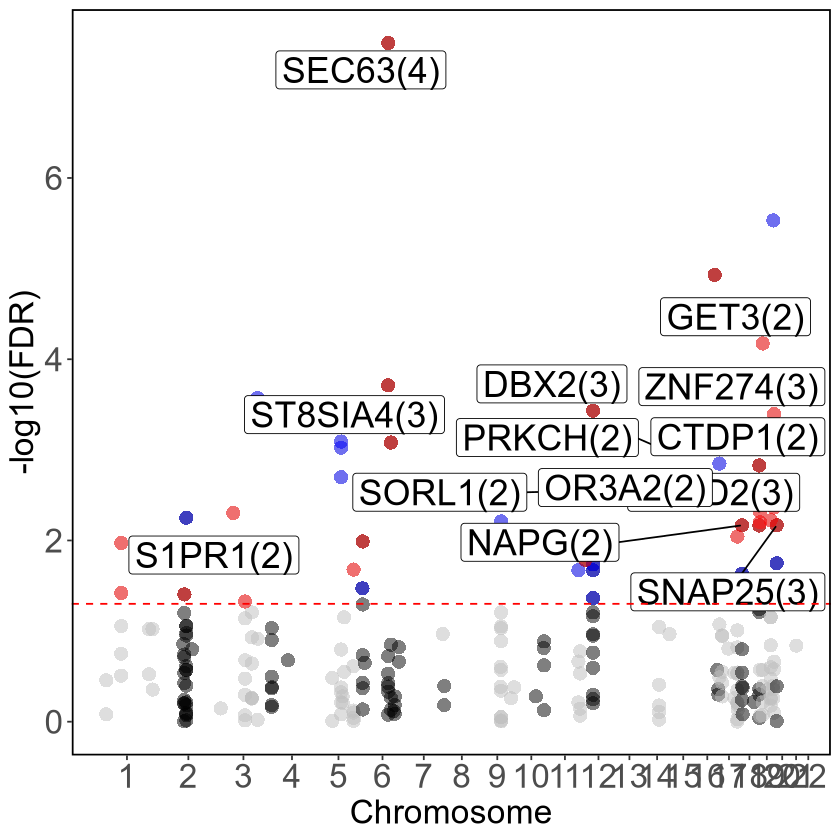

Retained 509 of 509 variants after filter.

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_number = as.numeric(gsub("chr", "", chr))`.
Caused by warning:
! NAs introduced by coercion”


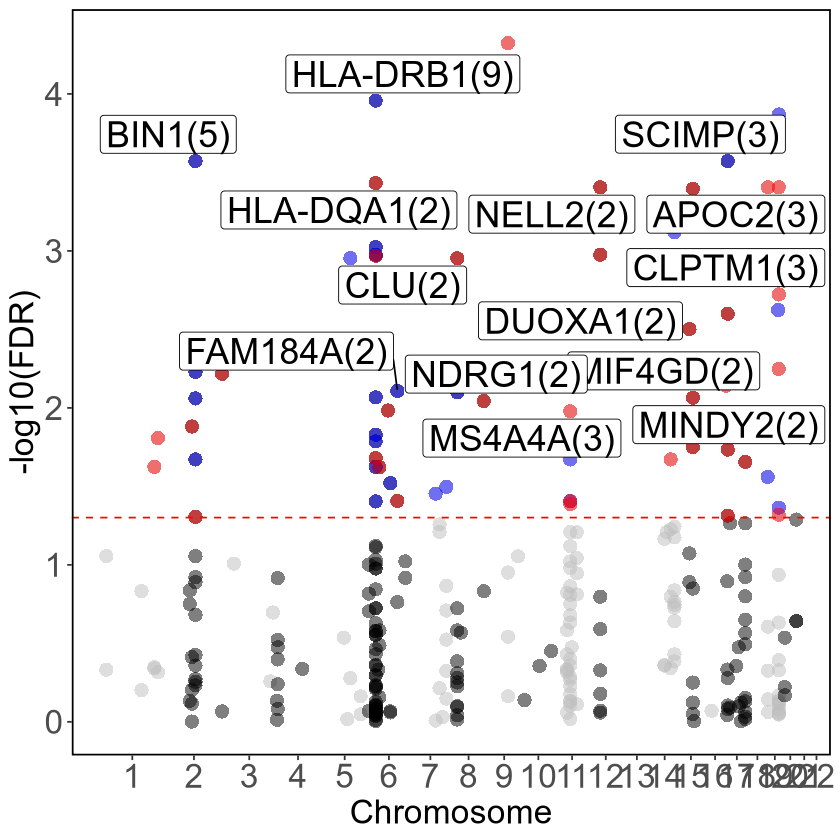

Retained 509 of 509 variants after filter.

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_number = as.numeric(gsub("chr", "", chr))`.
Caused by warning:
! NAs introduced by coercion”


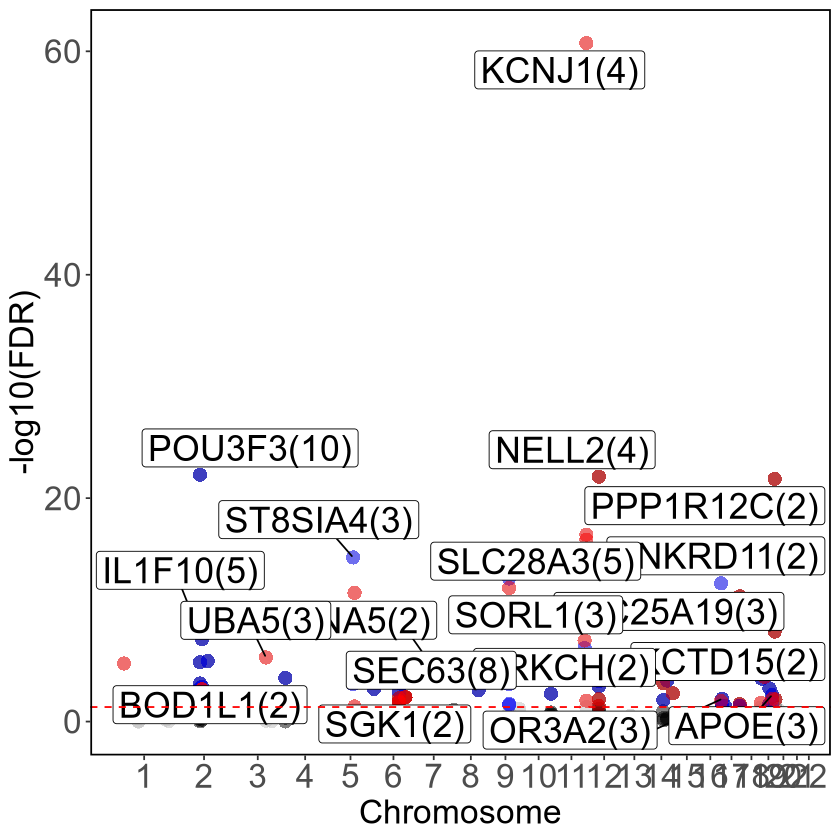

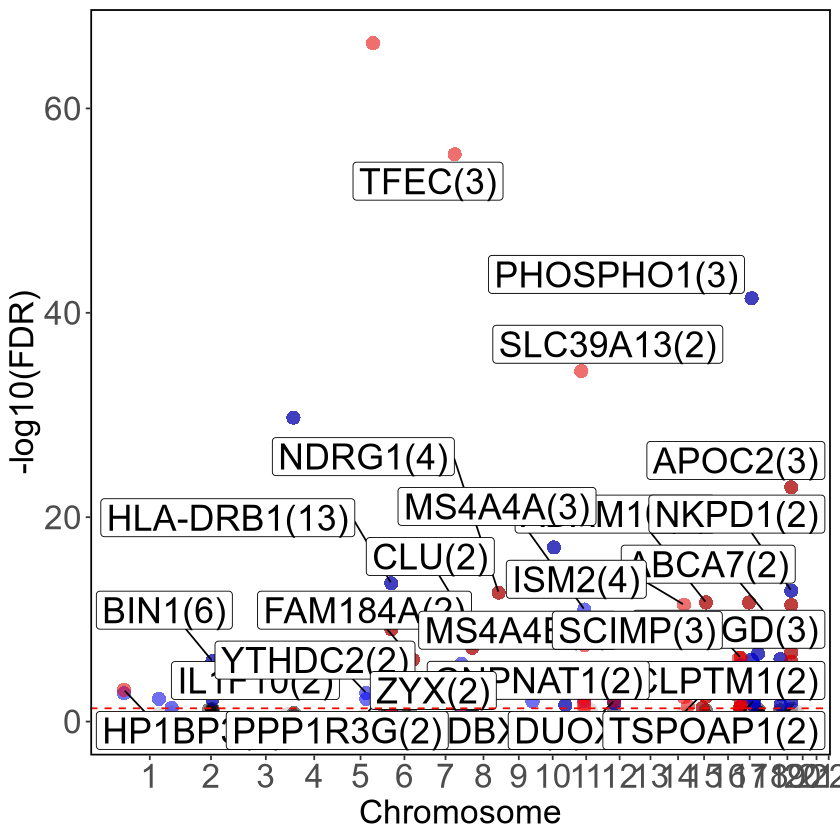

In [6]:
library(ggrepel)   # text labels
library(ggplot2)   # plotting
library(dplyr)     # data wrangling

create_manhattan_plot <- function(df_mac_path,
                                  chrom_sizes_path,
                                  snp_type,
                                  output_file,
                                  variant_filter_path = NULL) {
  ## 1. Read data --------------------------------------------------------------
  df_mac <- read.csv(df_mac_path, header = TRUE, row.names = 1)

  ## 1a. Optional: keep only variants listed in `variant_filter_path`
  if (!is.null(variant_filter_path)) {
    keep_ids <- readLines(variant_filter_path)
    df_mac   <- df_mac[rownames(df_mac) %in% keep_ids, ]
    message(sprintf("Retained %d of %d variants after filter.",
                    nrow(df_mac), length(keep_ids)))
  }

## 2. Usual filtering --------------------------------------------------------
library(stringr)   # for str_ helpers

filtered_data <- df_mac %>%
  ## 2a. collapse categories -----------------------------------------------
  mutate(
    ## normalise: trim spaces, force lower-case
    freq_class = str_to_lower(str_trim(Rare_Low_Common)),

    ## collapse Rare + Low Frequency into one bucket (“RareLow”)
    variant_group = case_when(
      freq_class == "common"        ~ "Common",
      freq_class %in% c("rare",
                        "low frequency")  ~ "RareLow",
      TRUE ~ NA_character_           # unexpected level
    )
  ) %>%
  ## 2b. keep only rows that match requested group and centre --------------
  filter(
    center %in% c("SNPCENTER", "PEAKCENTER"),
    variant_group == snp_type
  ) %>%
  ## 2c. flags for plotting --------------------------------------------------
  mutate(
    is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"),
    is_highlight_up   = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no")
  )


  ## 3. Chromosome positions ---------------------------------------------------
  chrom_sizes <- read.table(chrom_sizes_path, header = FALSE, sep = "\t",
                            col.names = c("chr", "chr_size")) %>%
    mutate(chr_number = as.numeric(gsub("chr", "", chr)),
           chr_size   = as.numeric(chr_size)) %>%
    filter(!chr_number %in% c("X", "Y")) %>%
    arrange(chr_number) %>%
    mutate(tot = cumsum(chr_size) - chr_size,
           center = tot + chr_size / 2)

  don <- filtered_data %>%
    left_join(chrom_sizes, by = "chr_number") %>%
    arrange(chr_number, pos_hg38) %>%
    mutate(Chromosome = pos_hg38 + tot,
           neglogFDR  = -log10(fdr))

  ## 4. Gene-level labels ------------------------------------------------------
  significant_data  <- don %>% filter(fdr <= 0.05)
  significant_counts <- significant_data %>%
    group_by(closest_protein_coding_gene_TSS) %>%
    summarise(SigSNP_count = n())

  don <- don %>%
    left_join(significant_counts, by = "closest_protein_coding_gene_TSS") %>%
    mutate(label = ifelse(!is.na(SigSNP_count) & SigSNP_count >= 2,
                          paste0(closest_protein_coding_gene_TSS, "(", SigSNP_count, ")"),
                          NA))

  label_data <- don %>%
    filter(!is.na(label)) %>%
    group_by(closest_protein_coding_gene_TSS) %>%
    slice_max(order_by = neglogFDR, n = 1, with_ties = FALSE) %>%
    ungroup()

  ## 5. Plot -------------------------------------------------------------------
  chrom_colors <- rep(c("grey", "black"), length.out = length(unique(don$chr_number)))

  manhattan_plot <- ggplot(don, aes(x = Chromosome, y = neglogFDR)) +
    geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 4, stroke = 0) +
    scale_color_manual(values = chrom_colors) +
    scale_x_continuous(labels = chrom_sizes$chr_number,
                       breaks = chrom_sizes$center) +
    geom_point(data = subset(don, is_highlight_down == "yes"),
               color = "blue", alpha = 0.5, size = 4, shape = 16, stroke = 0) +
    geom_point(data = subset(don, is_highlight_up == "yes"),
               color = "red",  alpha = 0.5, size = 4, shape = 16, stroke = 0) +
    geom_label_repel(data = label_data, aes(label = label),
                     size = 7.5, max.overlaps = Inf) +
    geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +
    theme_bw() +
    theme(
      legend.position    = "none",
      panel.border       = element_rect(color = "black", fill = NA, size = 1),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank(),
      panel.grid.major.y = element_blank(),   # or element_line()
      panel.grid.minor.y = element_blank(),   # or element_line()
      axis.title.x       = element_text(size = 20),
      axis.title.y       = element_text(size = 20),
      axis.text          = element_text(size = 20)
    ) +
    labs(x = "Chromosome", y = "-log10(FDR)")

  ## 6. Save & show ------------------------------------------------------------
  ggsave(output_file, plot = manhattan_plot, width = 14, height = 8, dpi = 300)
  print(manhattan_plot)
}
create_manhattan_plot(
  df_mac_path         = "allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv",
  chrom_sizes_path    = "/media/zihengc/T7/genome/hg38.chrom.subset.sizes",
  snp_type            = "RareLow",
  output_file         = "manhattan_plot_brain_rare_count3_highestLabel2.pdf",
  variant_filter_path = "indexing/ML_sig_variants_brain.txt"     # <- NEW
)

create_manhattan_plot(
  df_mac_path         = "allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv",
  chrom_sizes_path    = "/media/zihengc/T7/genome/hg38.chrom.subset.sizes",
  snp_type            = "Common",
  output_file         = "manhattan_plot_brain_common_count3_highestLabel2.pdf",
  variant_filter_path = "indexing/ML_sig_variants_brain.txt"
)

# Example usage:
create_manhattan_plot(
  df_mac_path = "allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv",
  chrom_sizes_path = "/media/zihengc/T7/genome/hg38.chrom.subset.sizes",
  snp_type = 'RareLow',
  output_file = "manhattan_plot_mac_rare_count3_highestLabel2.pdf",
  variant_filter_path = "indexing/ML_sig_variants_immune.txt"     # <- NEW
)
create_manhattan_plot(
  df_mac_path = "allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv",
  chrom_sizes_path = "/media/zihengc/T7/genome/hg38.chrom.subset.sizes",
  snp_type = 'Common',
  output_file = "manhattan_plot_mac_common_count3_highestLabel2.pdf",
  variant_filter_path = "indexing/ML_sig_variants_immune.txt"     # <- NEW
)

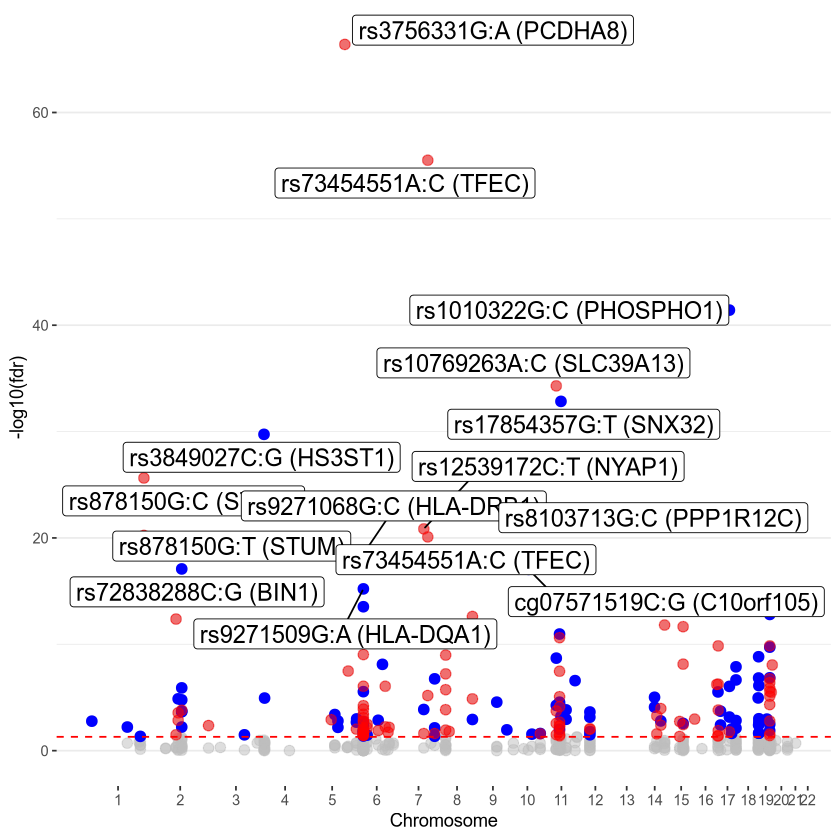

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Common", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 15, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_mac_common.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


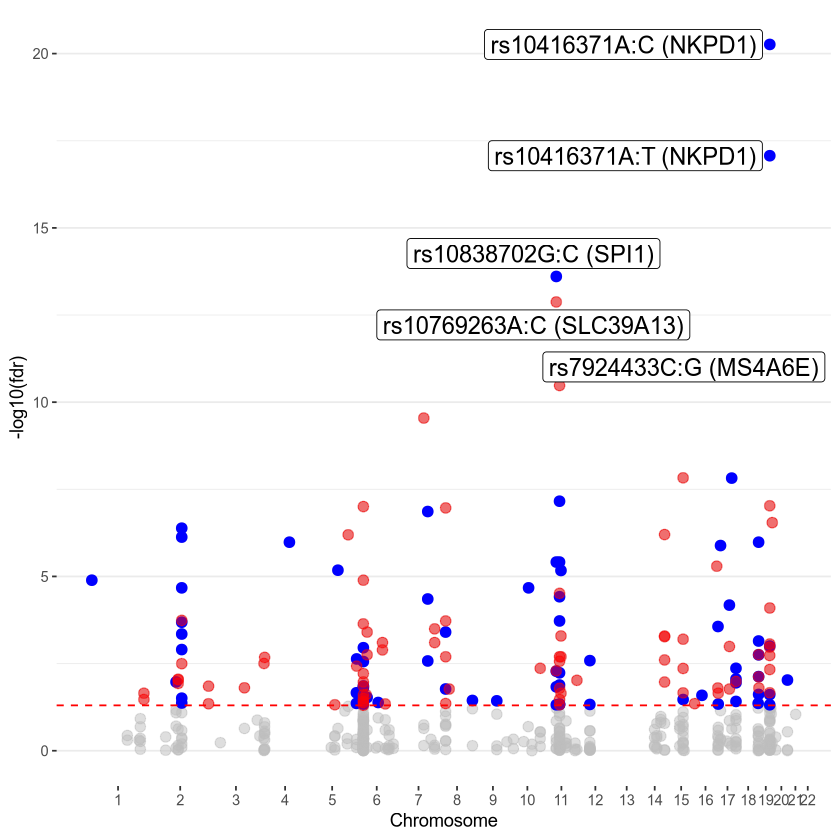

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240719_comparative_HEK293T_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Common", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 10, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_HEK293T_common.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


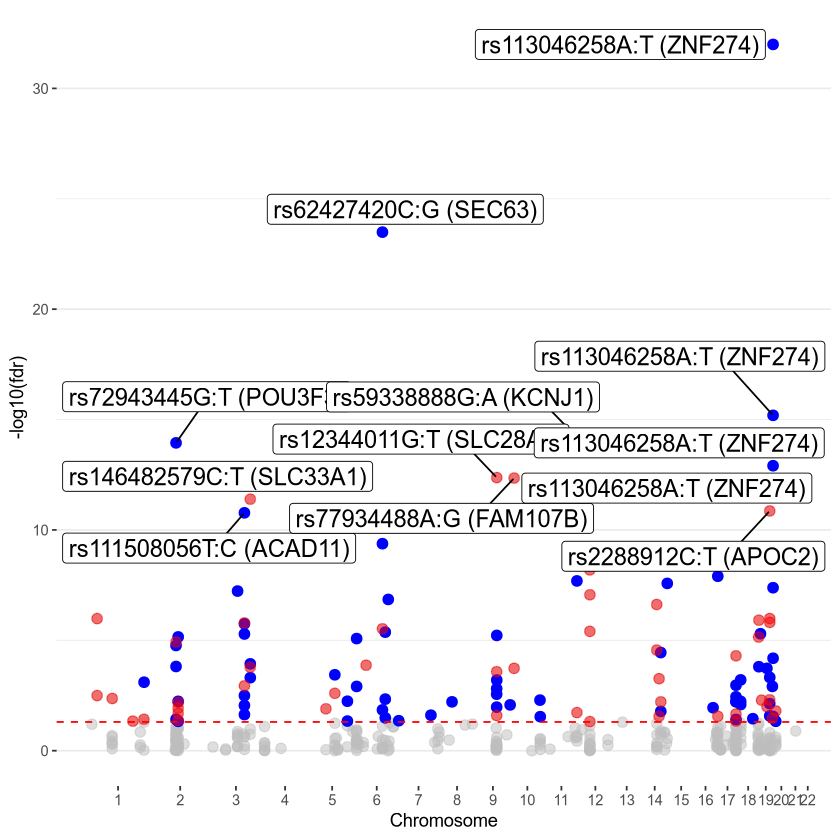

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240719_comparative_HEK293T_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Rare", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 10, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_HEK293T_rare.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


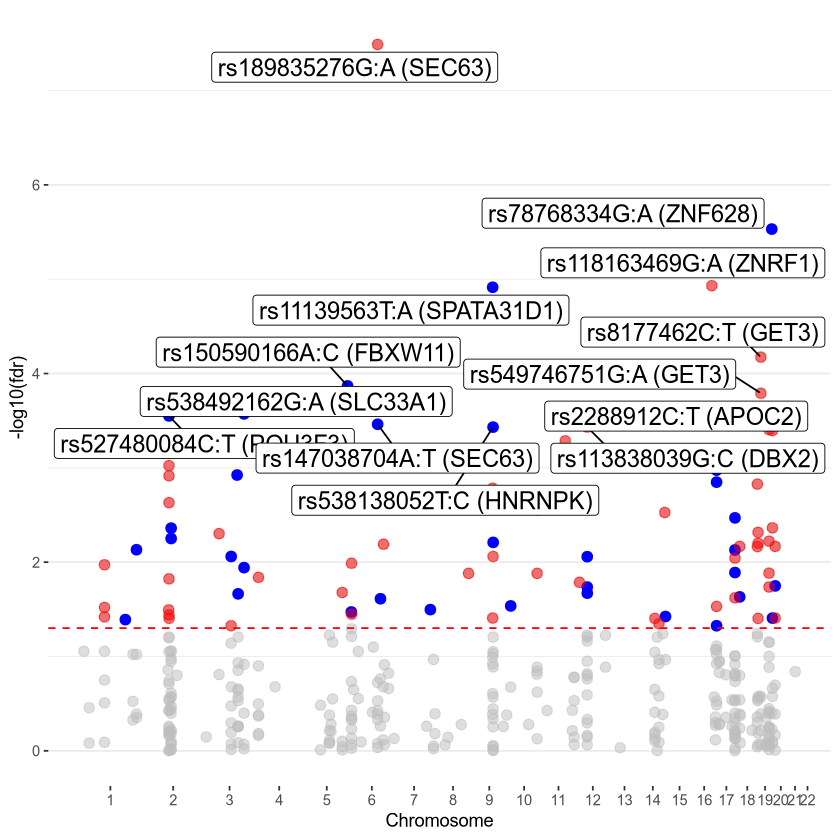

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Rare", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 3.4, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_Brain_rare.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


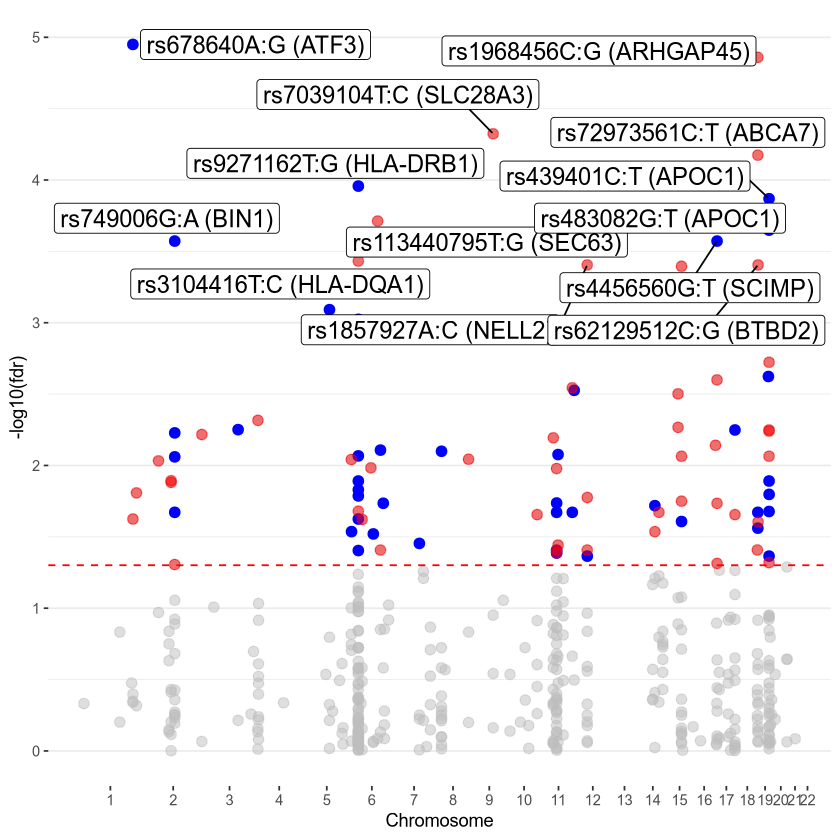

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Common", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 3.4, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_Brain_common.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


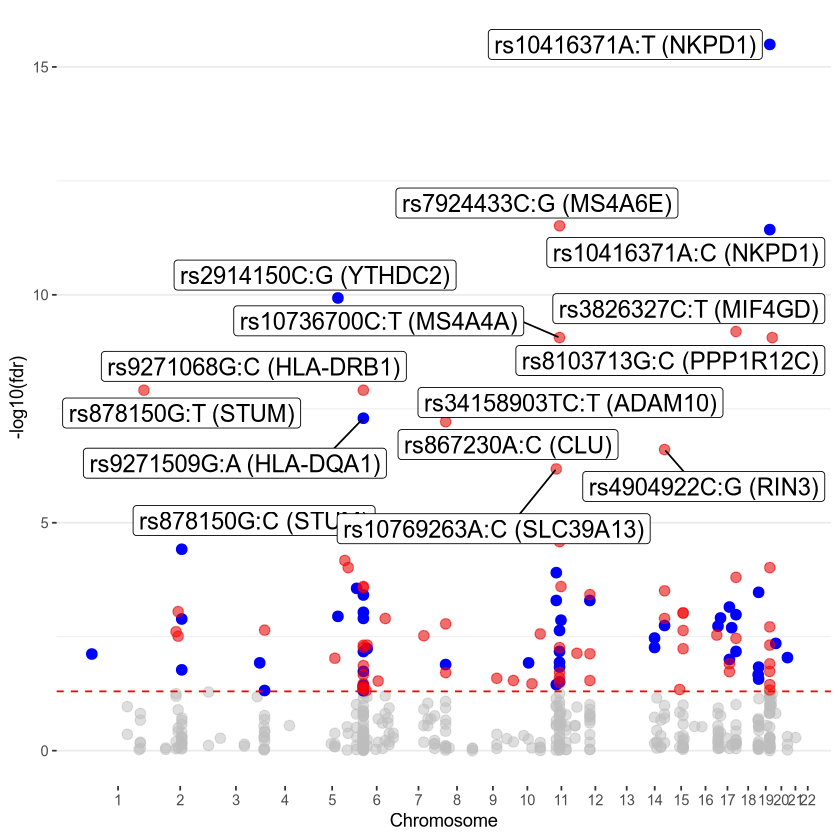

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240812_comparative_HMC3_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Common", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 5, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_HMC3_common.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


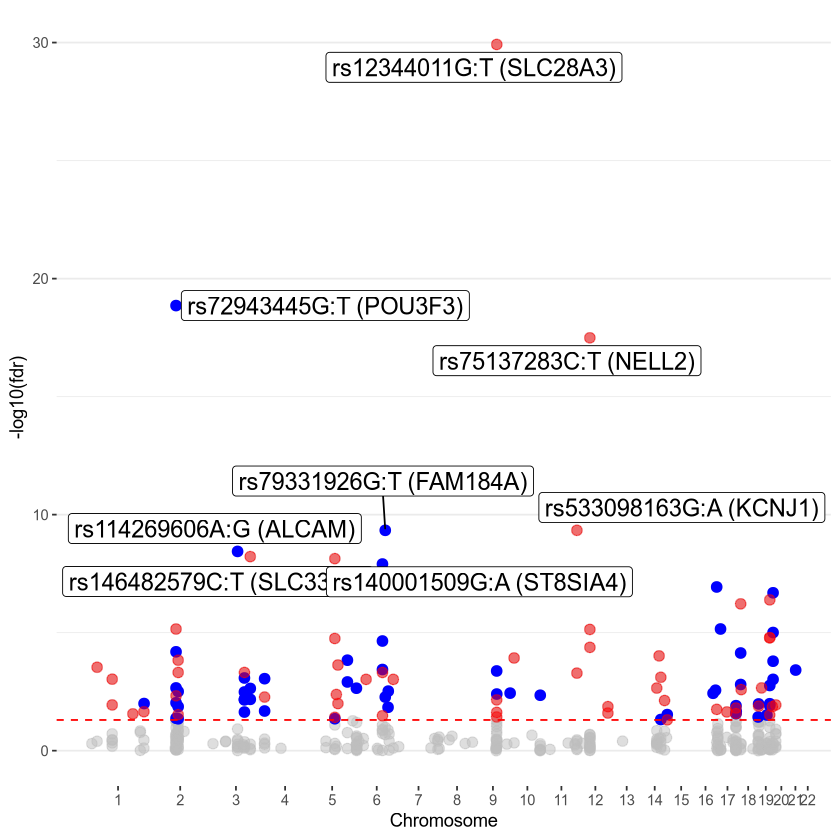

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240812_comparative_HMC3_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Rare", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 8, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_HMC3_rare.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


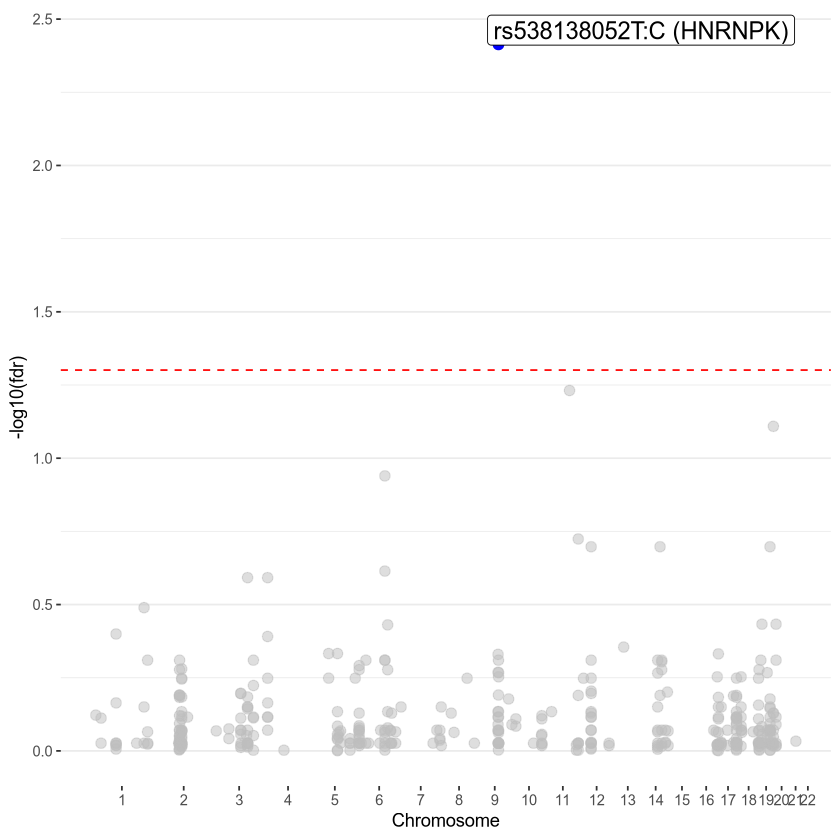

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Rare", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > -log10(0.05), "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_mono_rare.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


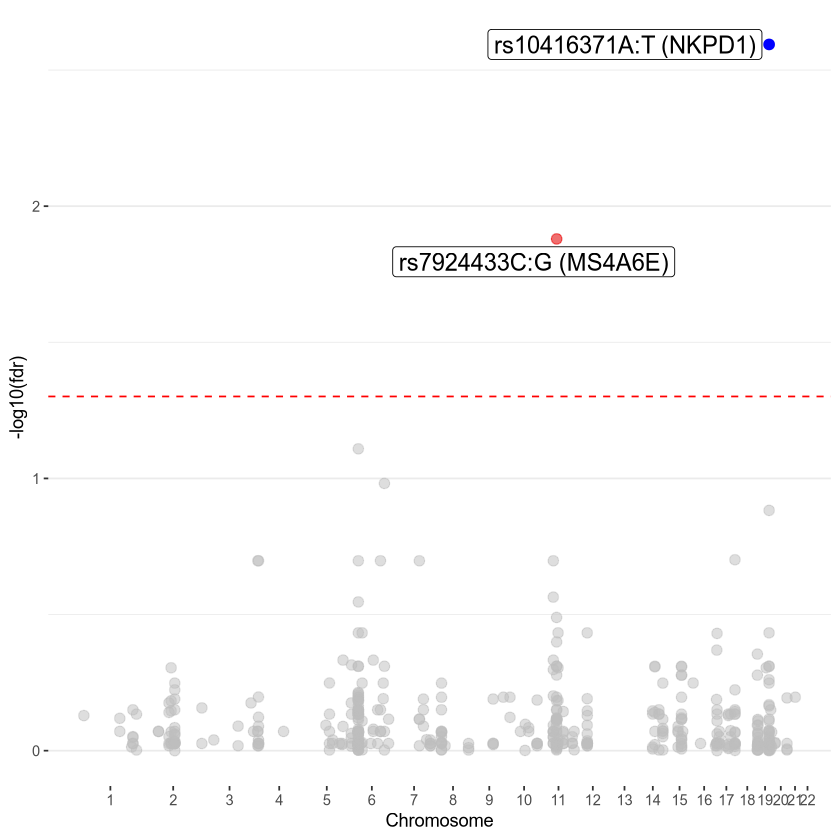

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240719_comparative_THP1Monocyte_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Common", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > -log10(0.05), "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_mono_common.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


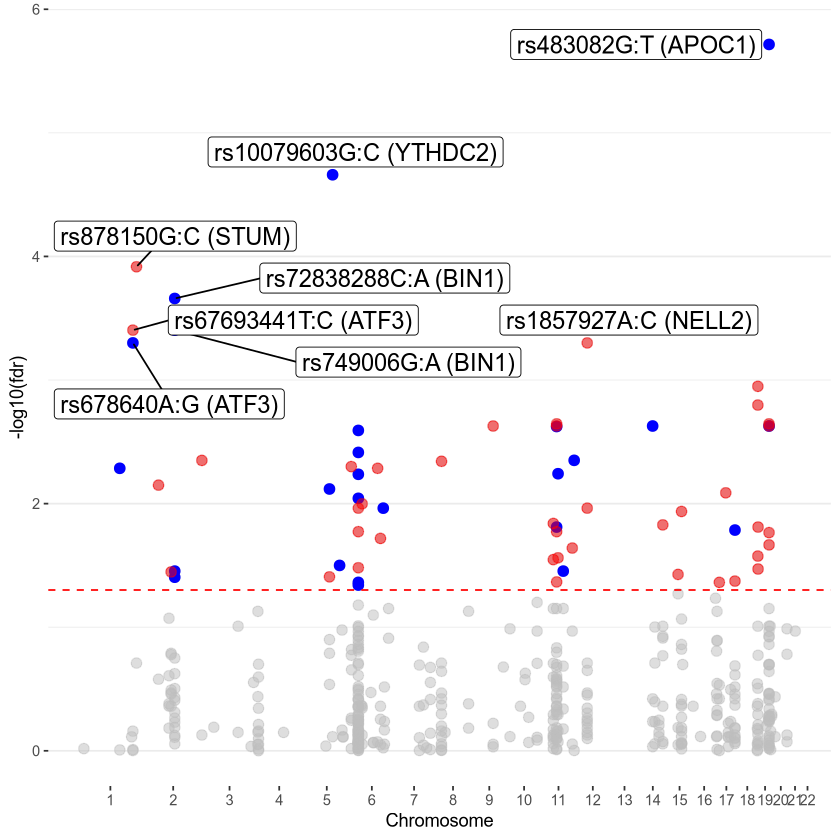

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240814_comparative_GutR1R2merged20240404_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Common", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 2.6, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_Gut_common.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)


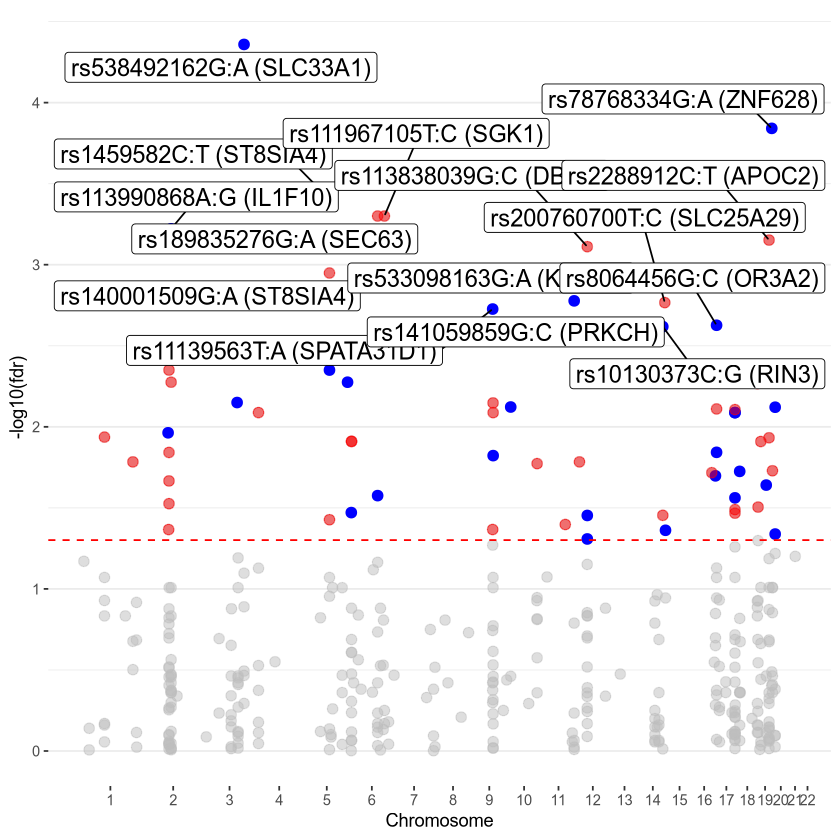

In [ ]:
# Load necessary libraries
library(ggrepel)  # For adding text labels to points on the plot
library(ggplot2)  # For creating the plot
library(dplyr)    # For data manipulation

# Load the data for THP1 Macrophage allele differences
df_mac <- read.csv("allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240814_comparative_GutR1R2merged20240404_alleleOnly.csv", 
                   header = TRUE, row.names = 1)

# Filter the data to include only rows where the 'center' is either SNPCENTER or PEAKCENTER and 'Rare_Common' is 'Rare'
filtered_data <- subset(df_mac, center %in% c("SNPCENTER", "PEAKCENTER"))
filtered_data <- filtered_data[filtered_data$Rare_Common == "Rare", ]

# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_down = ifelse(logFC_converted > 0 & fdr < 0.05, "yes", "no"))
# Mark rows of interest directly in the filtered data
filtered_data <- filtered_data %>%
  mutate(is_highlight_up = ifelse(logFC_converted < 0 & fdr < 0.05, "yes", "no"))
# Load the chromosome sizes from the hg38 reference genome
chrom_sizes <- read.table('/media/zihengc/T7/genome/hg38.chrom.subset.sizes', 
                          header = FALSE, sep = "\t", col.names = c("chr", "chr_size"))

# Extract and process chromosome number, removing X and Y chromosomes
chrom_sizes$chr_number <- gsub("chr", "", chrom_sizes$chr)
chrom_sizes <- chrom_sizes %>% filter(!chr_number %in% c("X", "Y"))
chrom_sizes$chr_number <- as.numeric(chrom_sizes$chr_number)

# Sort chromosome sizes by chromosome number
chrom_sizes <- chrom_sizes %>%
  mutate(chr_size = as.numeric(chr_size)) %>%
  arrange(chr_number) %>%
  mutate(tot = cumsum(chr_size) - chr_size) %>%
  mutate(center = tot + chr_size / 2)

# Join filtered data with chromosome sizes and calculate cumulative SNP positions
don <- filtered_data %>%
  left_join(chrom_sizes, by = c("chr_number" = "chr_number")) %>%
  arrange(chr_number, pos_hg38) %>%
  mutate(Chromosome = pos_hg38 + tot) %>%
  mutate(is_annotate = ifelse(-log10(fdr) > 2.6, "yes", "no"))

# Define alternating colors for chromosomes (grey and black)
chrom_colors <- rep(c("grey", "grey"), ceiling(length(unique(don$chr_number))/2))[1:length(unique(don$chr_number))]

# Create the Manhattan plot
manhattan_plot <- ggplot(don, aes(x = Chromosome, y = -log10(fdr))) +
  geom_point(aes(color = as.factor(chr_number)), alpha = 0.5, size = 1.3*2) +  # Plot SNPs with 50% transparency
  scale_color_manual(values = chrom_colors) +
  scale_x_continuous(labels = chrom_sizes$chr_number, breaks = chrom_sizes$center) +
  geom_point(data = subset(don, is_highlight_down == "yes"), color = "blue", alpha = 6, size = 1.3*2) +
  geom_point(data = subset(don, is_highlight_up == "yes"), color = "red", alpha = 0.5, size = 1.3*2)+  # Highlighted SNPs with 50% transparency
  geom_label_repel(data = subset(don, is_annotate == "yes"), aes(label = rsid_gene_tss), size = 2.5*2) +
  geom_hline(yintercept = -log10(0.05), color = "red", linetype = "dashed") +  # Significance threshold line
  theme_bw() +
  theme(
    legend.position = "none",  # Hide the legend
    panel.border = element_blank(),  # Remove panel borders
    panel.grid.major.x = element_blank(),  # Remove major grid lines for X axis
    panel.grid.minor.x = element_blank()   # Remove minor grid lines for X axis
  )

# Save the Manhattan plot with high resolution
ggsave("manhattan_plot_Gut_rare.pdf", plot = manhattan_plot, width = 14, height = 8, dpi = 300)

# Display the plot in the R console
print(manhattan_plot)
